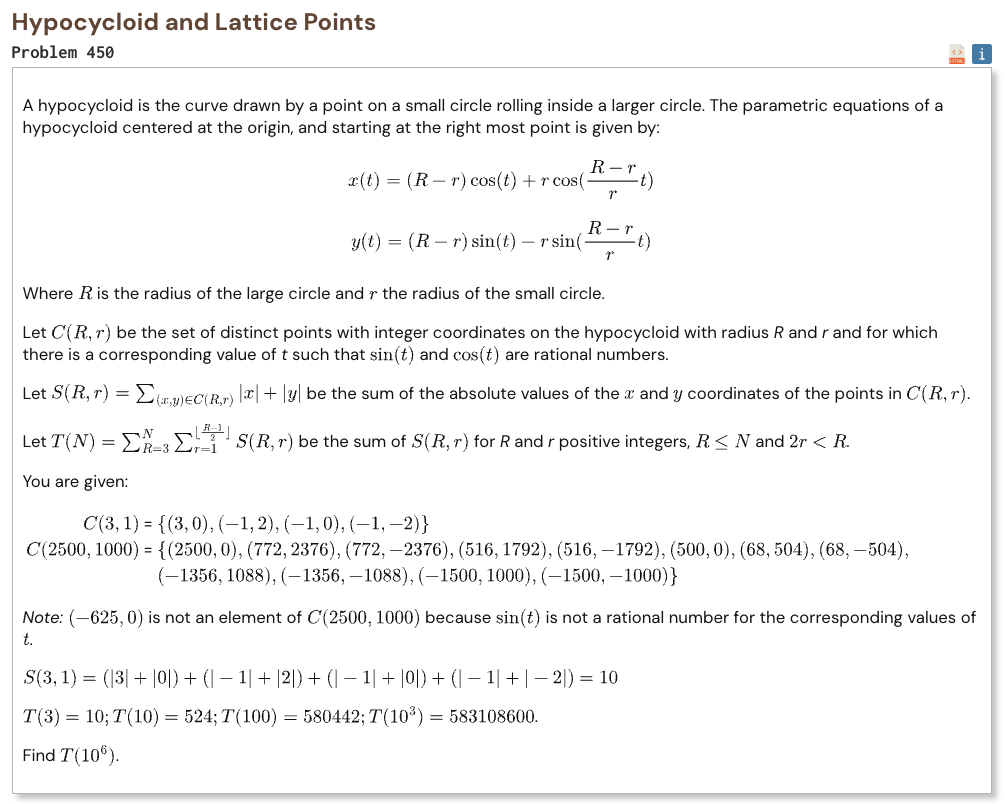

## Initial approach

-   reduce each radius pair by their greatest common divisor so the same hypocycloid shape is handled only once
-   separate the simple rational circle points on the coordinate axes from all other rational points
-   count the axis points in bulk using the Möbius function instead of checking every radius pair separately
-   group equal floor division values together so the large summations can skip whole ranges at once
-   generate the remaining rational circle points from primitive Pythagorean triples
-   use exact Gaussian integer powers to avoid floating point errors when testing those extra points
-   add every valid scale of each reduced point and combine it with the main axis contribution

In [1]:
%%time

from math import gcd, isqrt

N = 10**6

def mobius_sieve(n):
    mu = [0] * (n + 1)
    mu[1] = 1
    primes = []
    composite = [False] * (n + 1)

    for i in range(2, n + 1):
        if not composite[i]:
            primes.append(i)
            mu[i] = -1

        for p in primes:
            x = i * p

            if x > n:
                break

            composite[x] = True

            if i % p == 0:
                mu[x] = 0
                break

            mu[x] = -mu[i]

    return mu

def build_prefix(mu):
    n = len(mu) - 1

    prefix = [0] * (n + 1)
    prefix_odd = [0] * (n + 1)

    total = 0
    total_odd = 0

    for i in range(1, n + 1):
        total += mu[i] * i

        if i % 2 == 1:
            total_odd += mu[i] * i

        prefix[i] = total
        prefix_odd[i] = total_odd

    return prefix, prefix_odd

def pair_count(n):
    if n <= 2:
        return 0

    m = (n - 1) // 2

    return m * (n - m - 1)

def sum_a(n):
    return (n + 1) * pair_count(n) // 2

def sum_b(n):
    if n <= 2:
        return 0

    m = (n - 1) // 2

    return m * (m + 1) * (3 * n - 4 * m - 2) // 6

def odd_pair_sum_b(n):
    M = (n - 2) // 2

    if M <= 0:
        return 0

    m = (M - 1) // 2

    if m < 0:
        return 0

    s1 = m * (m + 1) // 2
    s2 = m * (m + 1) * (2 * m + 1) // 6

    return M * (m + 1) ** 2 - 4 * s2 - 2 * s1

def mod4_pair_sum_b(n):
    result = 0

    M1 = (n - 2) // 4

    if M1 > 0:
        m = (M1 - 1) // 2

        if m >= 0:
            s1 = m * (m + 1) // 2
            s2 = m * (m + 1) * (2 * m + 1) // 6
            result += M1 * (m + 1) * (2 * m + 1)
            result -= 8 * s2 + 2 * s1

    M3 = (n - 6) // 4

    if M3 > 0:
        m = (M3 - 1) // 2

        if m >= 0:
            s1 = m * (m + 1) // 2
            s2 = m * (m + 1) * (2 * m + 1) // 6
            result += M3 * (m + 1) * (2 * m + 3)
            result -= 8 * s2 + 6 * s1

    return result

def mobius_weighted_sum(m, prefix, func):
    result = 0
    left = 1

    while left <= m:
        q = m // left
        right = m // q

        result += (prefix[right] - prefix[left - 1]) * func(q)

        left = right + 1

    return result

mu = mobius_sieve(N)
prefix, prefix_odd = build_prefix(mu)

cache = {}

def reduced_axis_sum(m):
    if m in cache:
        return cache[m]

    a_part = mobius_weighted_sum(m, prefix, sum_a)
    b_part = mobius_weighted_sum(m, prefix, sum_b)
    odd_part = mobius_weighted_sum(m, prefix_odd, odd_pair_sum_b)
    mod4_part = mobius_weighted_sum(m, prefix_odd, mod4_pair_sum_b)

    value = 4 * a_part + 2 * b_part + 2 * odd_part - 4 * mod4_part

    cache[m] = value

    return value

def axis_total(n):
    result = 0
    left = 1

    while left <= n:
        q = n // left
        right = n // q

        scale_sum = (left + right) * (right - left + 1) // 2

        result += scale_sum * reduced_axis_sum(q)

        left = right + 1

    return result

def primitive_triples(cmax):
    triples = []

    limit = isqrt(2 * cmax) + 3

    for m in range(2, limit + 1):
        for n in range(1, m):
            if (m - n) % 2 == 0:
                continue

            if gcd(m, n) != 1:
                continue

            c = m * m + n * n

            if c > cmax:
                break

            a = m * m - n * n
            b = 2 * m * n

            triples.append((a, b, c))

    return triples

def gaussian_power(real, imag, exponent):
    result_real = 1
    result_imag = 0

    base_real = real
    base_imag = imag

    while exponent > 0:
        if exponent % 2 == 1:
            result_real, result_imag = (
                result_real * base_real - result_imag * base_imag,
                result_real * base_imag + result_imag * base_real
            )

        base_real, base_imag = (
            base_real * base_real - base_imag * base_imag,
            2 * base_real * base_imag
        )

        exponent //= 2

    return result_real, result_imag

def non_axis_total(n):
    result = 0

    max_a = 1

    while 3 ** (max_a + 1) <= n:
        max_a += 1

    for a_power in range(2, max_a + 1):
        cmax = int(n ** (1 / a_power)) + 2

        while cmax ** a_power > n:
            cmax -= 1

        triples = primitive_triples(cmax)

        for b_power in range(1, a_power):
            if gcd(a_power, b_power) != 1:
                continue

            for a, b, c in triples:
                denominator = c ** a_power

                if denominator * (a_power + b_power) > n:
                    continue

                variants = set()

                for u, v in ((a, b), (b, a)):
                    for sign_u in (1, -1):
                        for sign_v in (1, -1):
                            variants.add((sign_u * u, sign_v * v))

                for real, imag in variants:
                    real_a, imag_a = gaussian_power(real, imag, a_power)
                    real_b, imag_b = gaussian_power(real, imag, b_power)

                    scale = c ** (a_power - b_power)

                    numerator_x = (
                        a_power * real_b * scale
                        + b_power * real_a
                    )

                    numerator_y = (
                        a_power * imag_b * scale
                        - b_power * imag_a
                    )

                    common = gcd(
                        denominator,
                        gcd(abs(numerator_x), abs(numerator_y))
                    )

                    reduced_denominator = denominator // common

                    if reduced_denominator * (a_power + b_power) > n:
                        continue

                    x = numerator_x // common
                    y = numerator_y // common

                    kmax = n // (
                        reduced_denominator
                        * (a_power + b_power)
                    )

                    result += (
                        abs(x) + abs(y)
                    ) * kmax * (kmax + 1) // 2

    return result

result = axis_total(N) + non_axis_total(N)

print("Result:", result)

Result: 583333163984220940
CPU times: user 366 ms, sys: 9.83 ms, total: 376 ms
Wall time: 374 ms
